In [17]:
import os 
import numpy as np
data_dir = os.path.join("../dataset","1","data")
speakers_with_roi = ["s25_processed","s26_processed","s4_processed","s14_processed","s27_processed"]


In [18]:
import string 

chars = list(string.ascii_lowercase) + [' ']
blank_token = '-'
vocab = [blank_token] + chars

char2idx = {char: idx for idx, char in enumerate(vocab)}

In [19]:
from torch.utils.data import Dataset, DataLoader 
from torch.nn.utils.rnn import pad_sequence 
from torch.utils.data import random_split
from torchvision import transforms

import torch

class LipReadingDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir 
        self.transform = transform
        self.video_files = []
        self.align_files = []
        for speaker in os.listdir(data_dir):
            if speaker in speakers_with_roi: #becuase of computational resources, most of the speakers have not been processed for lip roi extraction. So we will only use the speakers that have been processed for lip roi extraction
                speaker_dir = os.path.join(data_dir, speaker)
                for file in os.listdir(speaker_dir):
                    if file.endswith(".mpg"):
                        self.video_files.append(os.path.join(speaker_dir, file))
                        alignment_file = os.path.join(speaker_dir,'align',file.replace(".mpg", ".align"))
                        self.align_files.append(alignment_file)
                    
                    
       
    def __len__(self):
            return len(self.video_files)

    def __getitem__(self, idx):
            video_path = self.video_files[idx]
            align_path = self.align_files[idx]
            """sample align file 
                0 23750 sil
                23750 29500 bin
                29500 34000 blue
                34000 35500 at
                35500 41000 f
                41000 47250 two
                47250 53000 now
                53000 74500 sil"""
            roi_path = video_path.replace(".mpg", "_lip_roi.npy")
            roi_data = np.load(roi_path)
            if self.transform:
                roi_data = self.transform(roi_data)
            with open(align_path, 'r') as f:
                lines = f.readlines()
                ids= []
                for line in lines:
                    start, end, word = line.strip().split() 
                    chars = list(word.lower())
                    ids.extend([char2idx[char] for char in chars if char in char2idx])
                ids = np.array(ids, dtype=np.int32)
                return roi_data, torch.tensor(ids, dtype=torch.int32)


#should resize further to 50 x 100 (128 x 128 is too big for our limited computational resources)
inp_transform=transforms.Compose([
     transforms.ToTensor(),
    #  transforms.Resize((100, 50))
])
dataset = LipReadingDataset(data_dir, transform=inp_transform) 
train_size = int(0.8 * len(dataset)) 
val_size = len(dataset) - train_size 

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

def collate_fn(batch):
    roi_data, ids = zip(*batch)
    #roi data is already resized to 100 x 50 but ids can't be batched if they are of different lenghts
    roi_data = torch.stack(roi_data) 
    ids = pad_sequence(ids, batch_first=True, padding_value=0)
    return roi_data, ids 



train_dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)  
val_dataloader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)      


In [13]:
class LipReadingModel(torch.nn.Module):
    def __init__(self,  hidden_size=128):
        super(LipReadingModel, self).__init__()
        #input shape is (batch_size, 75, 100, 50). 
        self.conv1 = torch.nn.Conv3d(in_channels=1, out_channels=16, kernel_size=(3,3,3), stride=(1,1,1), padding=(1,1,1))
      
        self.pool1 = torch.nn.MaxPool3d(kernel_size=(1,2,2), stride=(1,2,2))
        #(b,16, 75, 50,25)

        self.conv2 = torch.nn.Conv3d(in_channels=16, out_channels=32, kernel_size=(3,3,3), stride=(1,1,1), padding=(1,1,1))
      
        self.pool2 = torch.nn.MaxPool3d(kernel_size=(1,2,2), stride=(1,2,2))
        #(b, 32, 75, 25, 12)


        self.conv3 = torch.nn.Conv3d(in_channels=32, out_channels=64, kernel_size=(3,3,3), stride=(1,1,1), padding=(1,1,1))
        
        self.pool3 = torch.nn.MaxPool3d(kernel_size=(1,2,2), stride=(1,2,2))
        #(b, 64, 75, 12, 6)


        self.gru = torch.nn.GRU(input_size=64*12*6, hidden_size=hidden_size, num_layers=1, batch_first=True, bidirectional=True)
        self.linear = torch.nn.Linear(hidden_size*2 , len(vocab))
    
    def forward(self, x):
        x= self.conv1(x)
        x= self.pool1(x)

        x=self.conv2(x)
        x = self.pool2(x)
        x= self.conv3(x)
        x = self.pool3(x)

        #reshape x to (batch_size, 75, 64*12*6)
        print(x.shape)
        x = x.view(x.size(0), x.size(2),-1)
        print(x.shape)
        x,_ = self.gru(x)
        x = self.linear(x)
        return x 



model = LipReadingModel()
# Find the layer with the most parameters

max_params = 0
worst_layer = ""

for name, param in model.named_parameters():
    if param.numel() > max_params:
        max_params = param.numel()
        worst_layer = name

print(f"The culprit is: {worst_layer}")
print(f"It has: {max_params:,} parameters")

The culprit is: gru.weight_ih_l0
It has: 1,769,472 parameters


In [14]:
torch.Size([4, 64, 75, 16, 16])
torch.Size([4, 75, 16384])

torch.Size([4, 75, 16384])

torch.Size([75, 128, 128])


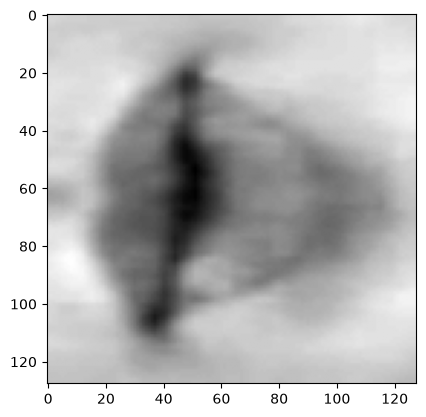

In [23]:
#plot sample roi imafe
sample_roi, sample_ids = dataset[0]
sample_roi= sample_roi.permute(1,0,2)
print(sample_roi.shape)
import matplotlib.pyplot as plt
plt.imshow(sample_roi[2], cmap='gray') 